In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

np.set_printoptions(precision=4, suppress=True)

<div style="height:2cm;">
<div style="float:center;width:100%;text-align:center;"><strong style="height:100px;color:darkred;font-size:40px;">GSVD and Tikhonov Regularization</strong></div>
</div>

# 1. Introduction

This notebook applies the generalized singular value decomposition to general-form Tikhonov regularization,

$$
\min_x\left(\lVert Ax-b\rVert_2^2+\mu^2\lVert Bx\rVert_2^2\right).
$$

It assumes the GSVD notation and computational conventions developed in:

- [**GSVD_intro.ipynb**](GSVD_intro.ipynb), for the decomposition and its geometric interpretation;
- [**GSVD_computations.ipynb**](GSVD_computations.ipynb), for the GEP, QR--CS, and LAPACK computations.

Only the formulas needed for regularization are recalled here.

The notebook develops:

- the Tikhonov solution in GSVD coordinates;
- generalized filter factors;
- the roles of mixed and exceptional GSVD directions;
- a noisy inverse-problem example;
- the residual–penalty tradeoff used in parameter selection.

____

For the numerical example, a compact symmetric-definite GEP helper computes normalized GSVD coordinates. The computational notebook explains why a production implementation should instead use orthogonal transformations or LAPACK.

# 2. General-Form Tikhonov Regularization

Consider the regularized least-squares problem

$$
\min_x\left(\lVert Ax-b\rVert_2^2+\mu^2\lVert Bx\rVert_2^2\right).
$$

The first term measures agreement with the observations. The second penalizes components considered undesirable by the regularization operator $B$. The parameter $\mu>0$ controls the balance between these two objectives.

This is **general-form Tikhonov regularization**. The special choice $B=I$ gives standard-form Tikhonov regularization.

Insert the GSVD

$$
A=UCX^{-1},
\qquad
B=VSX^{-1},
$$

and change coordinates by writing $x=Xy$. The two matrix actions become

$$
Ax=UCy,
\qquad
Bx=VSy.
$$

This is the useful step: both terms now depend on the same coordinate vector $y$, while $C$ and $S$ are diagonal on the active subspace.

Using the orthonormal columns of $U$ and $V$, the part of the objective that depends on $y$ is

$$
\lVert Cy-U^Tb\rVert_2^2
+\mu^2\lVert Sy\rVert_2^2.
$$

The component of $b$ orthogonal to the range of $A$ contributes only a constant and does not affect the minimizer.

Because $C$ and $S$ are diagonal, the minimization separates into scalar problems. The solution coordinates are

$$
y_i(\mu)=
\frac{c_i\,u_i^Tb}{c_i^2+\mu^2s_i^2}.
$$

Transforming back to the original coordinates gives

$$
x_\mu=Xy(\mu).
$$

The GSVD has converted a coupled regularized least-squares problem into independent decisions along the generalized right singular directions.

## 2.1 GSVD Filter Factors

For $c_i\ne0$, the unregularized coefficient along $x_i$ is $(u_i^Tb)/c_i$. Tikhonov regularization multiplies this coefficient by the filter factor

$$
\phi_i(\mu)=
\frac{c_i^2}{c_i^2+\mu^2s_i^2}
=
\frac{\gamma_i^2}{\gamma_i^2+\mu^2}.
$$

The filter factor makes the role of each generalized singular value explicit.

The two limiting regimes are:

- if $\gamma_i\gg\mu$, then $\phi_i(\mu)\approx1$ and the direction is retained;
- if $\gamma_i\ll\mu$, then $\phi_i(\mu)\approx0$ and the direction is suppressed.

As $\mu$ increases, progressively larger generalized singular values are damped.

The exceptional directions require separate interpretation:

- a pure-$A$ direction has $s_i=0$ and is not penalized by $B$;
- a pure-$B$ direction has $c_i=0$ and receives no information from the data term;
- a common-null direction is not determined by either term and requires an additional convention, usually the minimum-norm solution.

The generalized singular values therefore measure how strongly each right direction is informed by the observations relative to how strongly it is penalized.

#### **Algorithm Summary**

1. Compute a GSVD $A=UCX^{-1}$ and $B=VSX^{-1}$.
2. Project the data onto the left generalized singular vectors: $d=U^Tb$.
3. For each active direction, compute

   $$
   y_i=\frac{c_i d_i}{c_i^2+\mu^2s_i^2}.
   $$

4. Recover $x_\mu=Xy$ using a linear solve with $X^{-1}$ when possible.
5. Examine both $\lVert Ax_\mu-b\rVert_2$ and $\lVert Bx_\mu\rVert_2$ when selecting $\mu$.

The example requires normalized factors $U$, $C$, $S$, and $X$. Because its regularization matrix has full column rank, they can be obtained from the symmetric-definite GEP described in the computation notebook.

In [2]:
def gsvd_coordinates_via_gep(A, B):
    """Return normalized GSVD coordinates for a full-column-rank B.

    This compact helper forms normal equations for exposition. Use a tested
    LAPACK GSVD implementation for ill-conditioned production problems.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    if A.ndim != 2 or B.ndim != 2 or A.shape[1] != B.shape[1]:
        raise ValueError("A and B must have the same number of columns")
    if np.linalg.matrix_rank(B) < B.shape[1]:
        raise np.linalg.LinAlgError("B must have full column rank for this GEP helper")

    lam, Z = eigh(A.T @ A, B.T @ B)
    lam = np.maximum(lam, 0.0)
    s = 1.0 / np.sqrt(1.0 + lam)
    c = np.sqrt(lam) * s
    X = Z * s

    U = np.zeros((A.shape[0], A.shape[1]))
    active = c > 100 * np.finfo(float).eps
    U[:, active] = (A @ X[:, active]) / c[active]
    return {"U": U, "c": c, "s": s, "X": X}

# 3. Example: Smoothing Noisy Data

The forward matrix below attenuates successive coordinates, making recovery increasingly sensitive to noise. The regularization matrix combines first differences with a small identity component. Consequently, $B$ has full column rank and penalizes both roughness and overall magnitude.

In [3]:
def first_difference(n):
    D = np.zeros((n - 1, n))
    rows = np.arange(n - 1)
    D[rows, rows] = -1.0
    D[rows, rows + 1] = 1.0
    return D


def tikhonov_from_gsvd(factors, b, mu):
    """Solve general-form Tikhonov regularization from normalized GSVD factors."""
    U = factors["U"]
    c = factors["c"]
    s = factors["s"]
    X = factors["X"]
    denominator = c**2 + mu**2 * s**2
    y = np.divide(c * (U.T @ b), denominator,
                  out=np.zeros_like(c), where=denominator > 0)
    return X @ y


n = 20
grid = np.linspace(0.0, 1.0, n)
x_true = np.sin(np.pi * grid) + 0.35 * np.sin(3 * np.pi * grid)

A_reg = np.diag(np.logspace(0.0, -3.0, n))
B_reg = np.vstack((first_difference(n), 0.03 * np.eye(n)))

rng = np.random.default_rng(20260925)
b_exact = A_reg @ x_true
b_noisy = b_exact + 2.0e-3 * rng.standard_normal(n)

reg_factors = gsvd_coordinates_via_gep(A_reg, B_reg)
mu_values = [0.0, 0.01, 0.05, 0.2]
solutions = {mu: tikhonov_from_gsvd(reg_factors, b_noisy, mu) for mu in mu_values}

print("   mu       ||Ax-b||       ||Bx||       relative solution error    GSVD/direct")
for mu in mu_values:
    x_mu = solutions[mu]
    direct = np.linalg.solve(
        A_reg.T @ A_reg + mu**2 * (B_reg.T @ B_reg),
        A_reg.T @ b_noisy,
    )
    data_residual = np.linalg.norm(A_reg @ x_mu - b_noisy)
    penalty = np.linalg.norm(B_reg @ x_mu)
    solution_error = np.linalg.norm(x_mu - x_true) / np.linalg.norm(x_true)
    agreement = np.linalg.norm(x_mu - direct) / max(np.linalg.norm(direct), np.finfo(float).tiny)
    print(f"{mu:6.3f}   {data_residual:12.4e}   {penalty:10.4e}   "
          f"{solution_error:16.4e}   {agreement:10.3e}")

   mu       ||Ax-b||       ||Bx||       relative solution error    GSVD/direct
 0.000     1.6904e-12   6.3019e+00         1.3895e+00    1.993e-10
 0.010     5.6328e-03   5.8160e-01         2.3675e-01    3.588e-12
 0.050     7.7912e-03   5.2550e-01         2.7074e-01    7.127e-13
 0.200     2.8178e-02   4.8263e-01         2.9294e-01    1.199e-13


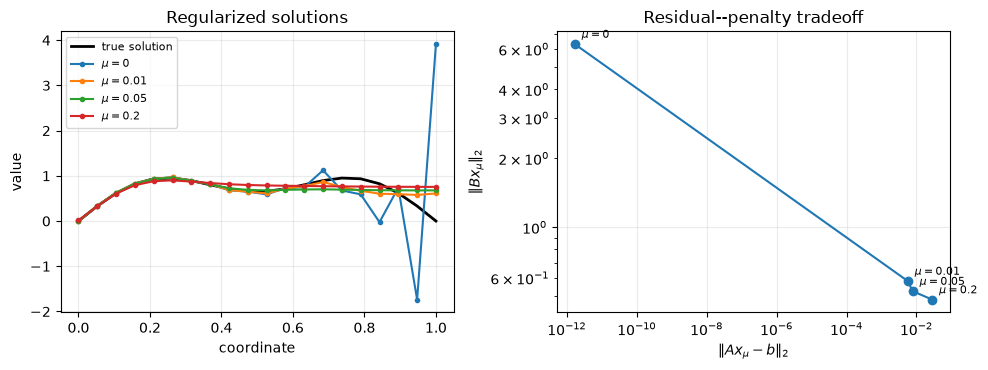

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].plot(grid, x_true, "k-", linewidth=2, label="true solution")
for mu in mu_values:
    axes[0].plot(grid, solutions[mu], marker="o", markersize=3, label=fr"$\mu={mu:g}$")
axes[0].set_title("Regularized solutions")
axes[0].set_xlabel("coordinate")
axes[0].set_ylabel("value")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

residuals = [np.linalg.norm(A_reg @ solutions[mu] - b_noisy) for mu in mu_values]
penalties = [np.linalg.norm(B_reg @ solutions[mu]) for mu in mu_values]
axes[1].loglog(residuals, penalties, "o-")
for mu, residual, penalty in zip(mu_values, residuals, penalties):
    axes[1].annotate(fr"$\mu={mu:g}$", (residual, penalty),
                     xytext=(5, 4), textcoords="offset points", fontsize=8)
axes[1].set_title("Residual--penalty tradeoff")
axes[1].set_xlabel(r"$\|Ax_\mu-b\|_2$")
axes[1].set_ylabel(r"$\|Bx_\mu\|_2$")
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

____

**Observe:**

- With $\mu=0$, the solution fits the noisy data most closely but strongly amplifies poorly determined components.
- Increasing $\mu$ reduces $\lVert Bx_\mu\rVert_2$ while increasing the data residual.
- An intermediate value gives a substantially better approximation to the true solution than either no regularization or excessive regularization.
- The GSVD-coordinate and direct solutions agree closely. The discrepancy is largest at $\mu=0$, where the unregularized problem and its normal equations are most ill-conditioned, and decreases substantially once regularization is applied.
- The residual--penalty curve displays the tradeoff used by parameter-choice methods such as the L-curve criterion.

<details>
<summary><strong>Check your understanding</strong></summary>

What happens to the filter factor $\phi_i(\mu)$ as $\mu$ increases, and which directions are suppressed first?

**Answer.** Each filter factor decreases monotonically. Directions with the smallest generalized singular values are suppressed first because the regularization term is strongest relative to the information supplied by $A$.
</details>

# 4. Parameter Selection

The regularization parameter should not be chosen solely to minimize the data residual: the unregularized solution does that by construction and may amplify noise severely. Instead, parameter-choice methods balance the residual against the penalty or use information about the noise.

Common approaches include:

- the **discrepancy principle**, when an estimate of the noise norm is available;
- the **L-curve criterion**, which examines curvature in the residual–penalty plot;
- **generalized cross-validation**, which estimates predictive error without a separate validation data set.

The small set of $\mu$ values in the example illustrates the tradeoff but does not implement an automatic parameter-choice method.

# 5. Take Away

- The GSVD diagonalizes the data-fit and regularization terms in a common right-coordinate system.
- The generalized singular values compare information supplied by $A$ with the penalty imposed by $B$.
- Tikhonov filter factors suppress directions for which the penalty dominates the observational information.
- Increasing $\mu$ reduces the penalty norm while increasing the data residual.
- Parameter selection is part of the inverse problem; the smallest residual does not generally give the most accurate solution.
- Computed solutions should be checked against both the residual norm and the penalty norm.

# 6. References

The following materials are available without a subscription.

1. P. C. Hansen, “Regularization, GSVD and Truncated GSVD,” UCLA Computational and Applied Mathematics Report CAM 89-10, 1989. [Full-text PDF](https://ww3.math.ucla.edu/camreport/cam89-10.pdf).

2. “Regularization of Least Squares Problems,” Hamburg University of Technology. [Full-text lecture notes](https://www.mat.tuhh.de/lehre/material/RegLS.pdf).

3. B. Hofmann, C. Hofmann, and P. Mathé, “Regularization of Inverse Problems,” 2020. [Open arXiv lecture notes](https://arxiv.org/abs/2001.00617).

4. M. Chung, J. G. Nagy, and D. P. O’Leary, “Optimal Regularization Parameters for General-Form Tikhonov Regularization,” 2014. [Open arXiv preprint](https://arxiv.org/abs/1407.1911).